# Computer Lab 4: Modeling El Niño-Southern Oscillation
This notebook will contain the entirety of the El Niño-Southern Oscillation computer lab.

## Setup
For this assignment, we will need `matplotlib.pyplot`, `numpy`, and `scipy.integrate`, as per usual. We will also need `sympy` again.

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate as integrate
import sympy

## Section 1: Equilibrium Solutions to the ENSO Model
We begin by looking at equilibrium solutions, as detailed in class.

### Part 1.1
Here, we are asked to seek steady-state solutions to the Vallis ENSO model. Recall that this model, in its simplest form, gives us three equations governing the zonal dynamics of the Pacific as

$$ \frac{d}{dt}U = B(T_e-T_w) + C(U_0-U) $$
$$ \frac{d}{dt}T_e = \frac{U}{\Delta x}T_w + A(T_0-T_e) $$
$$ \frac{d}{dt}T_w = \frac{-U}{\Delta x}T_e + A(T_0-T_w) $$

To find our steady-state solution, we set all of these derivatives equal to zero, and solve. Let's begin with the case where $U_0=-0.5\mathrm{ms}^{-1}$ and $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$. We are also given that $\Delta x = 7500\mathrm{km} = 7.5\times10^6\mathrm{m}$, $T_0=-15\degree\mathrm{C}$, $A = (6\;\mathrm{months})^{-1}$, and $C=(2\;\mathrm{months})^{-1}$. Let's quickly convert $A$ and $C$ to seconds by finding the average number of seconds in a month.

In [3]:
# Year = 365.2425 days x 24 hours x 60 minutes x 60 seconds
sec_year = 365.2425 * 24 * 60 * 60
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
print(A, C)

6.337747701362287e-08 1.9013243104086862e-07


We find that $A=6.338\times10^{-8}\mathrm{s}^{-1}$ and $C=1.901\times10^{-7}\mathrm{s}^{-1}$. With that, let's set up our first case and solve.

In [4]:
del_x = 7.5 * 10**6
T_0 = 15
U_0 = -0.5
B = 1.3 * 10**(-7)

T_e, T_w, U = sympy.symbols("T_e T_w U")

eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)    
eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

slns = sympy.nonlinsolve([eq1, eq2, eq3], [U, T_e, T_w])

In [5]:
num = 1
for U_sln, T_e_sln, T_w_sln in slns:
    print("Sln. #" + str(num) + "\n",
    "U = " + str(round(U_sln, 4)) + " m/s\n",
    "T_e = " + str(round(T_e_sln, 4)) + " degC\n",
    "T_w = " + str(round(T_w_sln, 4)) + " degC\n",
    "Resid. for eq1, eq2, eq3: ",
    round(B * (T_e_sln - T_w_sln) + C * (U_0 - U_sln), 4), 
    round(U_sln / del_x * T_w_sln + A * (T_0 - T_e_sln), 4), 
    round(-1 * U_sln / del_x * T_e_sln + A * (T_0 - T_w_sln), 4))
    num += 1


Sln. #1
 U = -3.3517 m/s
 T_e = -1.7896 degC
 T_w = 2.3811 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #2
 U = 0.0119 m/s
 T_e = 15.3650 degC
 T_w = 14.6163 degC
 Resid. for eq1, eq2, eq3:  0.0 0.0 0.0
Sln. #3
 U = 2.8398 m/s
 T_e = 2.8511 degC
 T_w = -2.0335 degC
 Resid. for eq1, eq2, eq3:  0.0 0 0


We find three real solutions, and for each solution, we have reached equilibrium with Vallis' state equations. This means our next step is to repeat this process for the next two cases, now allowing $B$ to vary.

In [6]:
# Define new variables
B_range = np.linspace(10**(-9), 10**(-6))
U_0 = 0

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [U, T_e, T_w])
    slns = np.array([(U_sln, T_e_sln, T_w_sln) for U_sln, T_e_sln, T_w_sln, in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([U_sln.is_real, T_e_sln.is_real, T_w_sln.is_real]) for U_sln, T_e_sln, T_w_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        #                                         T_w   -  T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[2] - sln[1]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

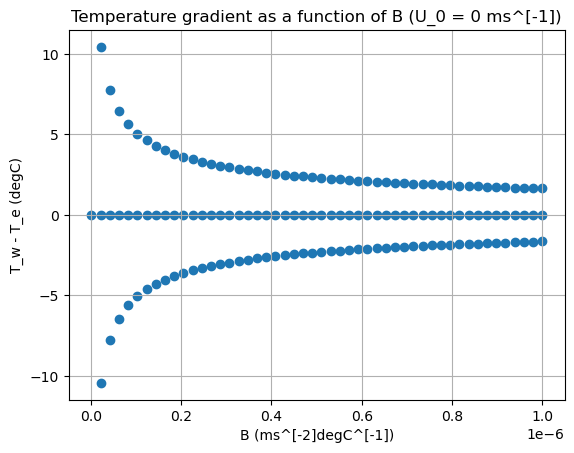

In [7]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = 0 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

As $B$ increases, we see that one of the solutions stays consistently at a $0\degree\mathrm{C}$ temperature gradient, and the other two --- symmetrically around the $0\degree\mathrm{C}$-axis --- approach the midpoint from what seem to be $+\infty$ and $-\infty$. Let's do the same analysis with $U_0=-0.5\mathrm{ms}^{-1}$.

In [8]:
# Define new variables
U_0 = -0.5

# Loop through possible values of B
T_diff = np.array([0, 0])
for B in B_range:

    # Set up equations
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [U, T_e, T_w])
    slns = np.array([(U_sln, T_e_sln, T_w_sln) for U_sln, T_e_sln, T_w_sln, in solved])

    # Determine which solutions are real and filter
    real_sln = np.array([all([U_sln.is_real, T_e_sln.is_real, T_w_sln.is_real]) for U_sln, T_e_sln, T_w_sln in solved])
    num_real_sln = int(slns[real_sln].size / 3)

    # Collect temperature differences
    for sln in slns[real_sln]:
        
        #                                         T_w   -  T_e
        T_diff = np.vstack([T_diff, np.array([B, sln[2] - sln[1]])])

# Delete first row (it was a filler row)
T_diff = np.delete(T_diff, (0), axis = 0)

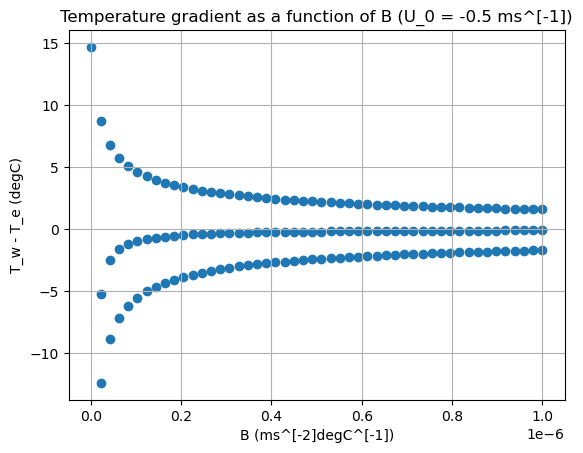

In [9]:
# Set up plot
fig, ax = plt.subplots()

# Plot data and label
ax.scatter(T_diff[:,0], T_diff[:,1])
ax.set_title("Temperature gradient as a function of B (U_0 = -0.5 ms^[-1])")
ax.set_ylabel("T_w - T_e (degC)")
ax.set_xlabel("B (ms^[-2]degC^[-1])")
ax.grid()

This case seems very similar to the prior, except now the "middle solution" also approaches $0\degree\mathrm{C}$ from $-\infty$. This makes sense; slight differences in initial conditions may change the behavior of our system dramatically in some regimes, but the asymptotic temperature gradient as $B$ increases seems to remain relatively invariant under the conditions we've tested.

### Part 1.2
Now, we want to find the stability of each of our solutions. In class, we discussed how the eigenvalues of our linearized matrix $\mathbf{E}$ will determine the stability of our system. As a refresher,

$$ \mathbf{E} = \begin{bmatrix}
                    -C & B & -B \\
                    \frac{T_w^*}{\Delta x} & -A & \frac{U^*}{\Delta x} \\
                    \frac{T_e^*}{\Delta x} & \frac{U^*}{\Delta x} & -A
                \end{bmatrix} $$

Let's start with the first case, where $U_0=-0.5\mathrm{ms}^{-1}$ and $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$.

In [10]:
B = 1.3 * 10**(-7)

T_e, T_w, U = sympy.symbols("T_e T_w U")

eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

slns = sympy.nonlinsolve([eq1, eq2, eq3], [U, T_e, T_w])

num = 1
for U_sln, T_e_sln, T_w_sln in slns:

    # Calculate E
    E = np.array([[-C, B, -B],
                   [T_w_sln / del_x, -A, U_sln / del_x],
                   [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
    
    # Find eigenvalues
    eigs = np.real(np.linalg.eig(E)[0])
    if any(eigs > 0):
        stability = "unstable"
    else:
        stability = "stable"
    
    # Print diagnostics
    print("Sln. #" + str(num) + "\n",
    "U = " + str(round(U_sln, 4)) + " m/s\n",
    "T_e = " + str(round(T_e_sln, 4)) + " degC\n",
    "T_w = " + str(round(T_w_sln, 4)) + " degC\n",
    "Eigenvalues = ", eigs,
    "\nStability = " + stability)
    num += 1

Sln. #1
 U = -3.3517 m/s
 T_e = -1.7896 degC
 T_w = 2.3811 degC
 Eigenvalues =  [ 4.89828244e-07 -2.96450769e-07 -5.10264860e-07] 
Stability = unstable
Sln. #2
 U = 0.0119 m/s
 T_e = 15.3650 degC
 T_w = 14.6163 degC
 Eigenvalues =  [-1.27546227e-07 -1.27546227e-07 -6.17949317e-08] 
Stability = stable
Sln. #3
 U = 2.8398 m/s
 T_e = 2.8511 degC
 T_w = -2.0335 degC
 Eigenvalues =  [-3.16074039e-07 -3.16074039e-07  3.15260694e-07] 
Stability = unstable


Here, we find that when $U=0.0119\mathrm{ms}^{-1}$, $T_e=15.365\degree\mathrm{C}$, and $T_w=14.6163\degree\mathrm{C}$, our system is stable; the other two solutions are not. Let's repeat this process for varying $B$ in the first case, where $U_0 = 0$.

In [11]:
# Set initial values
B_range_small = np.linspace(10**(-9), 10**(-6), 10)
U_0 = 0

# Iterate
for B in B_range_small:
    
    # Set up equation
    T_e, T_w, U = sympy.symbols("T_e T_w U")
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real, filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    real_slns = slns[real_sln]

    # Check all solutions
    num = 1
    print("For B = " + str(B))
    for sln in real_slns:

        # Isolate solutions
        T_e_sln, T_w_sln, U_sln = sln
        
        # Calculate E
        E = np.array([[-C, B, -B],
                    [T_w_sln / del_x, -A, U_sln / del_x],
                    [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
        
        # Find eigenvalues
        eigs = np.real(np.linalg.eig(E)[0])
        if any(eigs > 0):
            stability = "unstable"
        else:
            stability = "stable"
        
        # Print diagnostics
        print("Temp. gradient = " + str(round(T_w_sln - T_e_sln, 2)) + ": " + stability, end = "   ")
        num += 1
    print("\n---------------------------")


For B = 1e-09
Temp. gradient = 0: stable   
---------------------------
For B = 1.1199999999999998e-07
Temp. gradient = 4.85: unstable   Temp. gradient = -4.85: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 2.2299999999999997e-07
Temp. gradient = 3.46: unstable   Temp. gradient = -3.46: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 3.34e-07
Temp. gradient = 2.84: unstable   Temp. gradient = -2.84: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 4.45e-07
Temp. gradient = 2.46: unstable   Temp. gradient = -2.46: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 5.56e-07
Temp. gradient = 2.20: unstable   Temp. gradient = -2.20: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 6.669999999999999e-07
Temp. gradient = 2.01: unstable   Temp. gradient = -2.01: unstable   Temp. gradient = 0: stable   
---------------------------
For B = 7.7799999999999

It is clearly evident from the results above that for each of the non-zero values of $T_w-T_e$, the system is unstable for $U_0=0\mathrm{ms}^{-1}$. However, when this gradient is $0\degree\mathrm{C}$, the system is stable. This correlates with the middle solution on the plot. Let's look at the other possibility, $U_0=-0.5\degree\mathrm{C}$.

In [12]:
# Set initial values
U_0 = -0.5

# Iterate
for B in B_range_small:
    
    # Set up equation
    T_e, T_w, U = sympy.symbols("T_e T_w U")
    eq1 = sympy.Eq(B * (T_e - T_w) + C * (U_0 - U), 0)
    eq2 = sympy.Eq(U / del_x * T_w + A * (T_0 - T_e), 0)
    eq3 = sympy.Eq(-U / del_x * T_e + A * (T_0 - T_w), 0)

    # Solve and isolate solutions
    solved = sympy.nonlinsolve([eq1, eq2, eq3], [T_e, T_w, U])
    slns = np.array([(T_e_sln, T_w_sln, U_sln) for T_e_sln, T_w_sln, U_sln in solved])

    # Determine which solutions are real, filter
    real_sln = np.array([all([T_e_sln.is_real, T_w_sln.is_real, U_sln.is_real]) for T_e_sln, T_w_sln, U_sln in solved])
    real_slns = slns[real_sln]

    # Check all solutions
    num = 1
    print("For B = " + str(B))
    for sln in real_slns:

        # Isolate solutions
        T_e_sln, T_w_sln, U_sln = sln
        
        # Calculate E
        E = np.array([[-C, B, -B],
                    [T_w_sln / del_x, -A, U_sln / del_x],
                    [T_e_sln / del_x, U_sln / del_x, -A]], dtype = float)
        
        # Find eigenvalues
        eigs = np.real(np.linalg.eig(E)[0])
        if any(eigs > 0):
            stability = "unstable"
        else:
            stability = "stable"
        
        # Print diagnostics
        print("Temp. gradient = " + str(round(T_w_sln - T_e_sln, 2)) + ": " + stability, end = "   ")
        num += 1
    print("\n---------------------------")


For B = 1e-09
Temp. gradient = 14.72: unstable   
---------------------------
For B = 1.1199999999999998e-07
Temp. gradient = 4.46: unstable   Temp. gradient = -5.28: unstable   Temp. gradient = -0.87: stable   
---------------------------
For B = 2.2299999999999997e-07
Temp. gradient = 3.26: unstable   Temp. gradient = -3.68: unstable   Temp. gradient = -0.43: stable   
---------------------------
For B = 3.34e-07
Temp. gradient = 2.70: unstable   Temp. gradient = -2.98: unstable   Temp. gradient = -0.29: stable   
---------------------------
For B = 4.45e-07
Temp. gradient = 2.36: unstable   Temp. gradient = -2.57: unstable   Temp. gradient = -0.22: stable   
---------------------------
For B = 5.56e-07
Temp. gradient = 2.12: unstable   Temp. gradient = -2.29: unstable   Temp. gradient = -0.17: stable   
---------------------------
For B = 6.669999999999999e-07
Temp. gradient = 1.94: unstable   Temp. gradient = -2.08: unstable   Temp. gradient = -0.14: stable   
---------------------

Our "middle solution" is still stable, with the positive- and negative-tending solutions remaining unstable. This is interesting --- even with the asymptotic behavior of the normal solution as $B$ gets very small, the solution remains stable. However, this is consistent with the first and second cases, and still represents the system with the smallest zonal climate variability. 

## Section 2: Time-varying Solutions
Now, we shift our focus to time-varying solutions. This section only has one "task", but it involves looking at several possible values to experiment with. For each set of values, we will also choose to look at the cases in which the temperature gradient is positive, negative, or zero. Let's begin directly with the first one.

### Case 1
$\mathit{U_0=-0.5ms^{-1}}$, $\mathit{B=1.3\times10^{-7}ms^{-2}\degree C^{-1}}$

Most of the rest of this section will be similar to this code, but let's take a second to understand how we will tackle this first task. We will employ `scipy.integrate`'s `odeint()` to integrate our system of ODEs with the initial conditions we choose for $T_e$ and $T_w$. We will run each simulation for ten years, then plot, then repeat for other selections of initial conditions. We will repeat this four times per set of values to understand the system's behavior under a wide range of physically realistic conditions, modeled as

$$ (T_{e,0}, T_{w,0})\in\{(15\degree\mathrm{C}, 15\degree\mathrm{C}), (-15\degree\mathrm{C}, -15\degree\mathrm{C}), (15\degree\mathrm{C}, 0\degree\mathrm{C}), (0\degree\mathrm{C}, 15\degree\mathrm{C}), (0\degree\mathrm{C}, 0\degree\mathrm{C})\} $$

Text(0.5, 0.01, 'Year')

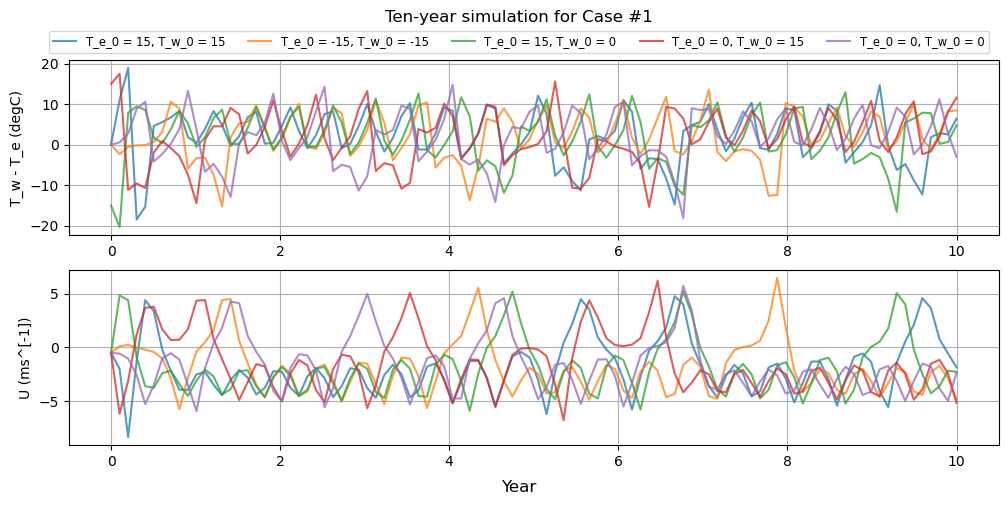

In [13]:
# Ensure our values are well-defined
del_x = 7.5 * 10**6
T_0 = 15
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
ten_year = np.linspace(0, sec_year * 10, 100)
sec_year = 365.2425 * 24 * 60 * 60

# Define system
def system_eq(y, t):
    U = y[0]; T_e = y[1]; T_w = y[2]
    eq_1 = B * (T_e - T_w) + C * (U_0 - U)
    eq_2 = U / del_x * T_w + A * (T_0 - T_e)
    eq_3 = -U / del_x * T_e + A * (T_0 - T_w)

    return np.array([eq_1, eq_2, eq_3])

# Vary values
U_0 = -0.5
B = 1.3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #1")
fig.supxlabel("Year")

Referring to the stability diagram for $U_0=-0.5\mathrm{ms}^{-1}$, it is clear that when $B=1.3\times10^{-7}ms^{-2}\degree C^{-1}$, none of the solutions settle at $T_w-T_e=0\degree\mathrm{C}$. This is reflected in our ten-year simulation; each solution seems to oscillate roughly between $T_w-T_e=0\degree\mathrm{C}$ and $T_w-T_e=10\degree\mathrm{C}$, with spikes at $T_w-T_e=\pm15\degree\mathrm{C}$. In each case, both the magnitude and frequency of the $U$ reversals (corresponding to El Niño events) seem realistic.

### Case 2
$\mathit{U_0=0ms^{-1}}$, $\mathit{B=1.3\times10^{-7}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

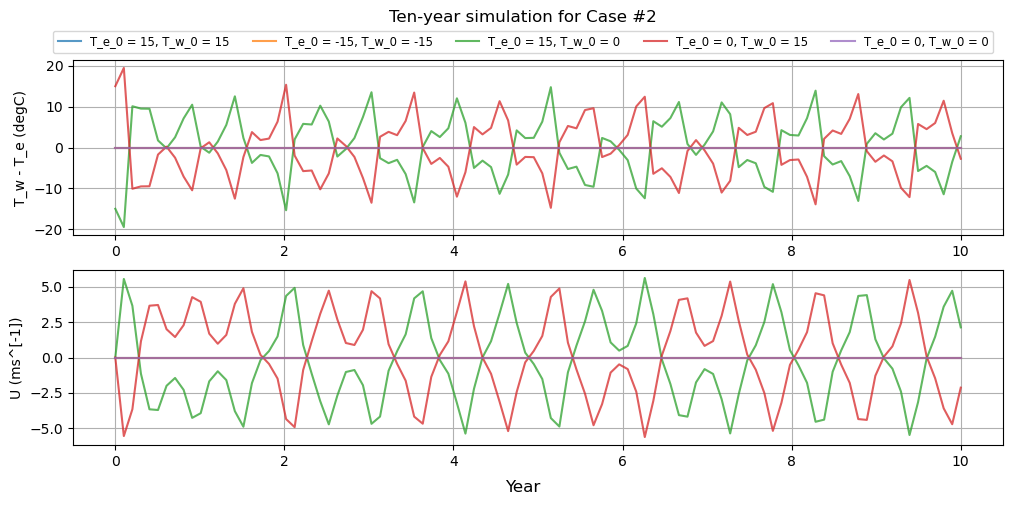

In [14]:
# Vary values
U_0 = 0
B = 1.3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #2")
fig.supxlabel("Year")

Referring to the stability diagram for $U_0=0ms^{-1}$, we find that the middle solution --- beginning with a temperature gradient of zero --- retains its zero temperature gradient as a stable solution, reflected in each simulation with a beginning gradient of zero (blue, orange, purple). The unstable solutions (red and green) that begin with a positive or negative temperature gradient then fluctuate nearly symmetrically in both temperature and current speed, which is similarly reflected in the stability diagram. This is not a realistic solution, as El Niño events are not symmetrical in magnitude or frequency.

### Case 3
$\mathit{U_0=-0.5ms^{-1}}$, $\mathit{B=2\times10^{-8}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

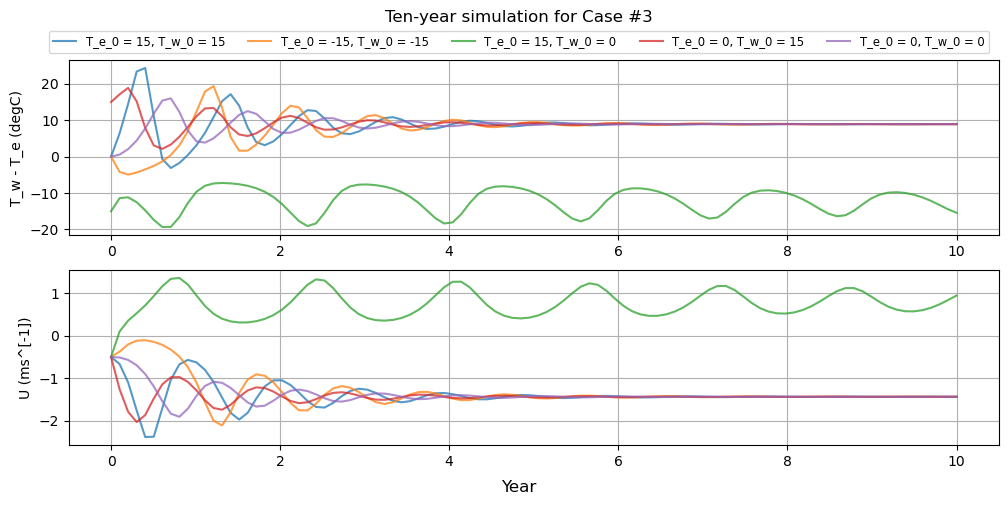

In [15]:
# Vary values
U_0 = -0.5
B = 2 * 10**(-8)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #3")
fig.supxlabel("Year")

We see that every solution for case 3 with an initial non-negative temperature gradient quickly stabilizes to a temperature gradient around $10\degree\mathrm{C}$. The set of initial conditions with a negative initial temperature gradient also seems to stabilize, albeit at a slower rate and to a lower gradient value. Once again looking at the plot for $U_0=-0.5\mathrm{ms}^{-1}$, we can understand that non-negative initial conditions, when we have our value of $B$, only tend towards the solution with a positive temperature gradient, while the negative initial conditions tend towards one of two negative-gradient solutions. This case is not very realistic, as this would presume that the ENSO system would stabilize, which it has and will not.

### Case 4
$\mathit{U_0=0ms^{-1}}$, $\mathit{B=2\times10^{-8}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

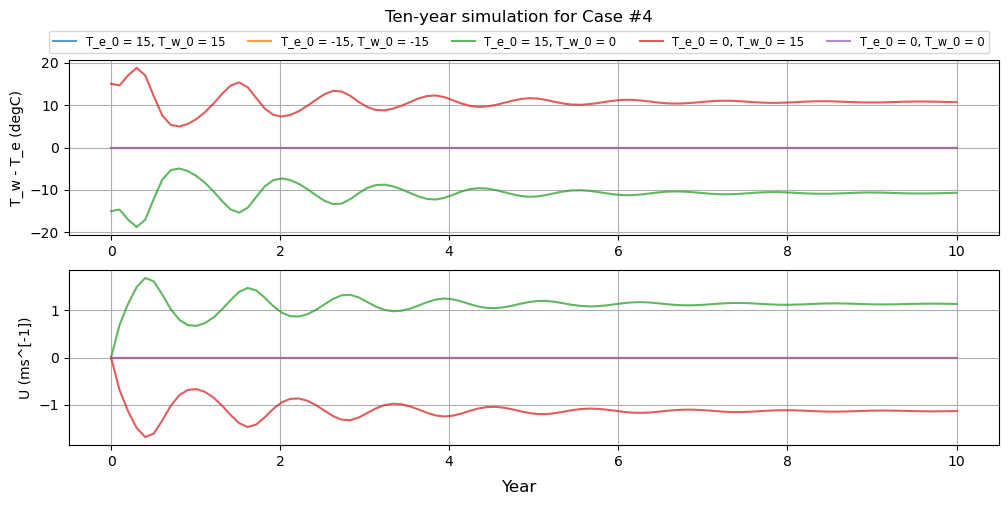

In [16]:
# Vary values
U_0 = 0
B = 2 * 10**(-8)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #4")
fig.supxlabel("Year")

Similar to case 2, we see that every instance with initial conditions of a zero temperature gradient remains at zero, which makes sense because this is a consistent stable solution for $U_0=0\mathrm{ms}^{-1}$. However, now the other two solutions stabilize, likely due to the fact that they are further away from the other solutions. This simulation is also unlikely to reflect physical reality for the same reasons as case 3.

### Case 5
$\mathit{U_0=-0.5ms^{-1}}$, $\mathit{B=2\times10^{-9}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

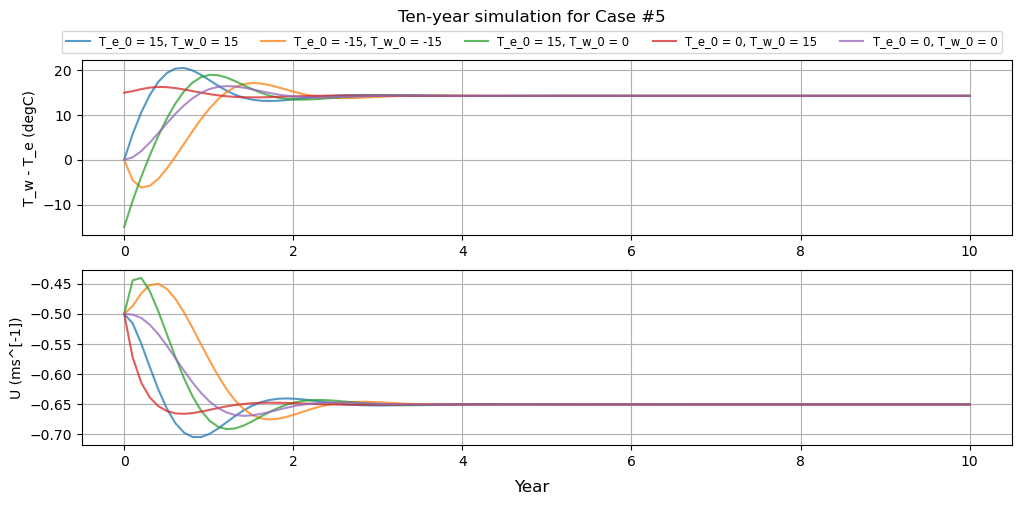

In [17]:
# Vary values
U_0 = -0.5
B = 2 * 10**(-9)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #5")
fig.supxlabel("Year")

In this case, $B$ appears to be so low that each set of initial conditions invariably is towards the one stable solution in our system (for $U_0=-0.5\mathrm{ms}^{-1}$, the two unstable solutions strongly diverge for low $B$). This is, once again, physically unlikely, as ENSO is not a stabilized system.

### Case 6
$\mathit{U_0=0ms^{-1}}$, $\mathit{B=2\times10^{-9}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

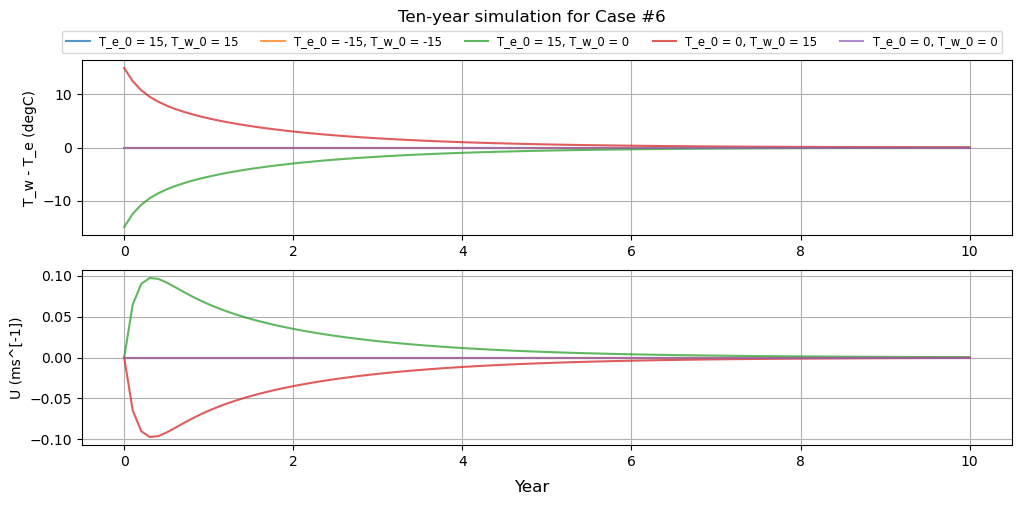

In [18]:
# Vary values
U_0 = 0
B = 2 * 10**(-9)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #6")
fig.supxlabel("Year")

Similar to cases 2 and 4, every solution with a zero initial temperature gradient remains at zero. However, similar to case 5, it seems that even the non-zero initial temperature gradients also tend towards this solution due to the large divergence of the solutions for low $B$. This is even less physically likely than case 5, as it presumes the Pacific surface currents may just stop.

### Case 7
$\mathit{U_0=-0.5ms^{-1}}$, $\mathit{B=3\times10^{-7}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

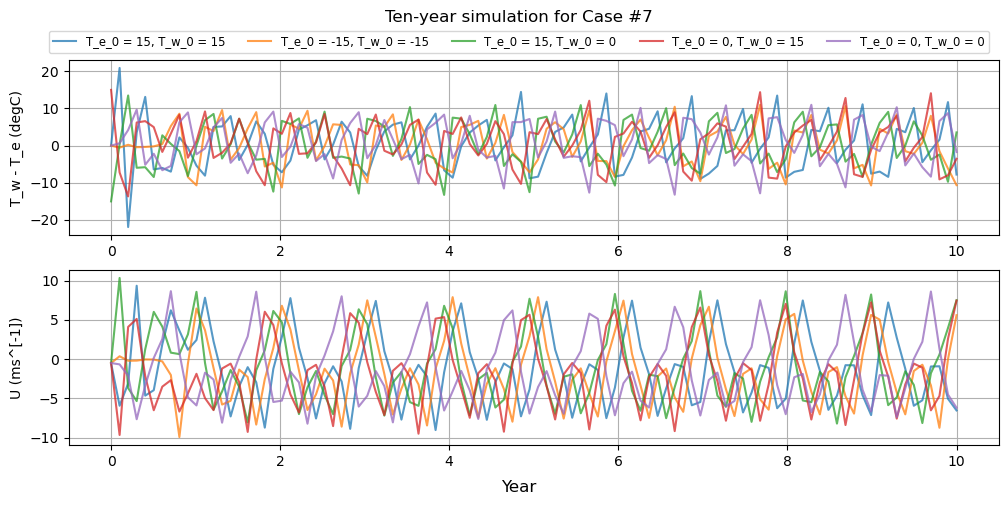

In [19]:
# Vary values
U_0 = -0.5
B = 3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #7")
fig.supxlabel("Year")

This is similar to case 1, so the instability of the system remains; however, the ENSO spikes have much greater frequency. This makes sense, as $B$ determines air-sea coupling, so a higher interchange between the two would speed up ENSO. This solution isn't exactly realistic due to its high frequency, but besides that, it's more believable than the stable solutions we've looked at.

### Case 8
$\mathit{U_0=0ms^{-1}}$, $\mathit{B=3\times10^{-7}ms^{-2}\degree C^{-1}}$

Text(0.5, 0.01, 'Year')

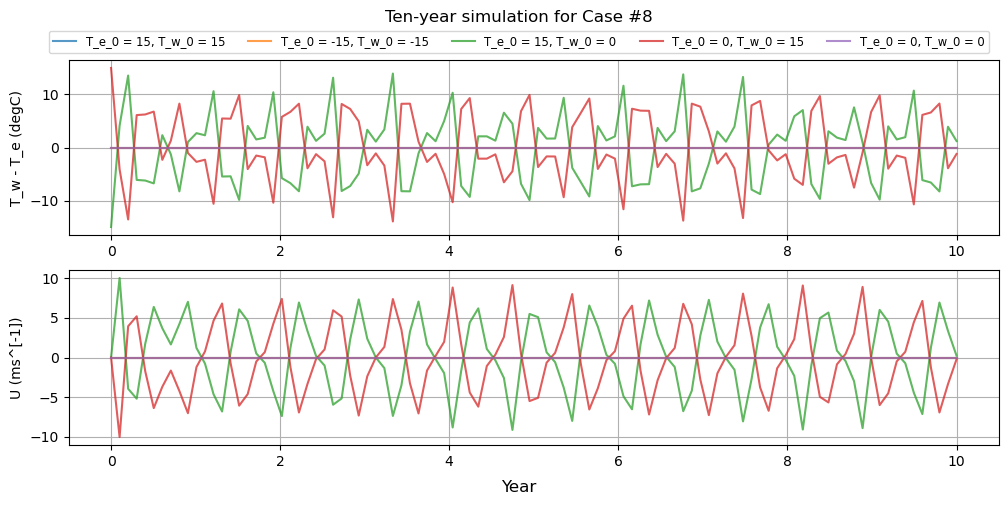

In [20]:
# Vary values
U_0 = 0
B = 3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #8")
fig.supxlabel("Year")

Once again, this case is similar to case 2, just with higher frequency for the same reasons as case 7. This case is still highly unrealistic, as even for the solutions that aren't just zero, it's unlikely for ENSO fluctuations to be both so fast and so symmetrical.

## Section 3: Variations in Seasonality and Basin Width
Now, we look at what occurs in our system when we allow key variables to differ in their values.

### Part 3.1
Here, we are asked to now let $U_0$ vary in time according to $U_0=-0.5+\sin(\omega t)$, where $\omega$ is some annual frequency. Once again, we say $B=1.3\times10^{-7}\mathrm{ms}^{-2}\degree\mathrm{C}^{-1}$; let's assume our initial conditions for temperature are the same for $T_e$ and $T_w$, where $T_e=T_w=15\degree\mathrm{C}$. Now, let's integrate our equations with varying values of $\omega$ and examine the results.

Text(0.5, 0.01, 'Year')

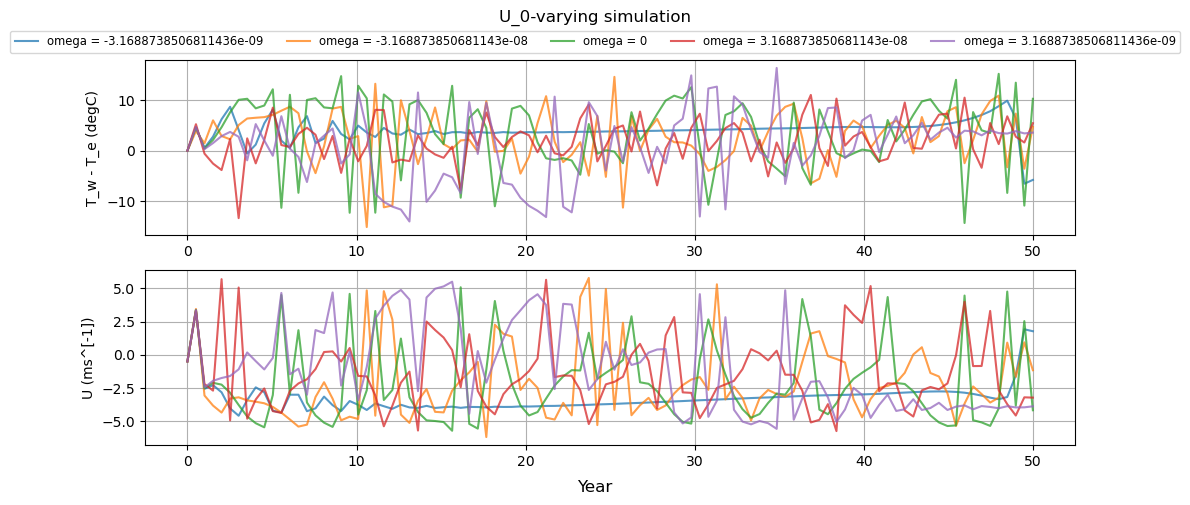

In [31]:
# Ensure our values are well-defined
del_x = 7.5 * 10**6
T_0 = 15
A = 1 / (6 / 12 * sec_year)
B = 1.3 * 10**(-7)
C = 1 / (2 / 12 * sec_year)
all_years = np.linspace(0, sec_year * 50, 100)
sec_year = 365.2425 * 24 * 60 * 60

# Define system
def system_eq(y, t):
    U = y[0]; T_e = y[1]; T_w = y[2]
    eq_1 = B * (T_e - T_w) + C * (-0.5 + np.sin(omega * t) - U)
    eq_2 = U / del_x * T_w + A * (T_0 - T_e)
    eq_3 = -U / del_x * T_e + A * (T_0 - T_w)

    return np.array([eq_1, eq_2, eq_3])

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Prepare month-of-start dictionary
month_of_start = {}

# Set initial conditions
init_conds = [-((sec_year * 10) ** (-1)), -(sec_year ** (-1)), 0, sec_year ** (-1), (sec_year * 10) ** (-1)]
i = 1
for omega in init_conds:

    sln = integrate.odeint(system_eq, [-0.5, 15, 15], all_years)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(all_years / sec_year, temp_grad, label = "omega = " + str(omega), alpha = 0.75)
    axs[1].plot(all_years / sec_year, U_vary, alpha = 0.75)

    # Find all El Nino values
    en_times_ind = np.where(U_vary > 0)
    en_times_ind_true = np.array([])

    # Isolate start months
    for index in en_times_ind[0]:
        if not np.isin(en_times_ind, index - 1).any():
            en_times_ind_true = np.append(en_times_ind_true, index)

    # Convert to month no. and add to data frame
    month_no = (all_years[en_times_ind_true.astype(int)] / sec_year * 12 % 12).astype(int)
    month_of_start['omega_' + str(i)] = np.where(month_no == 0, 12, month_no)
    i += 1

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("U_0-varying simulation")
fig.supxlabel("Year")

This system is much more chaotic than the equivalent case with $U_0=-0.5\mathrm{ms}^{-1}$ (case 1 above). This makes sense, as having our initial conditions vary with time only introduces more variability into our system's solutions.

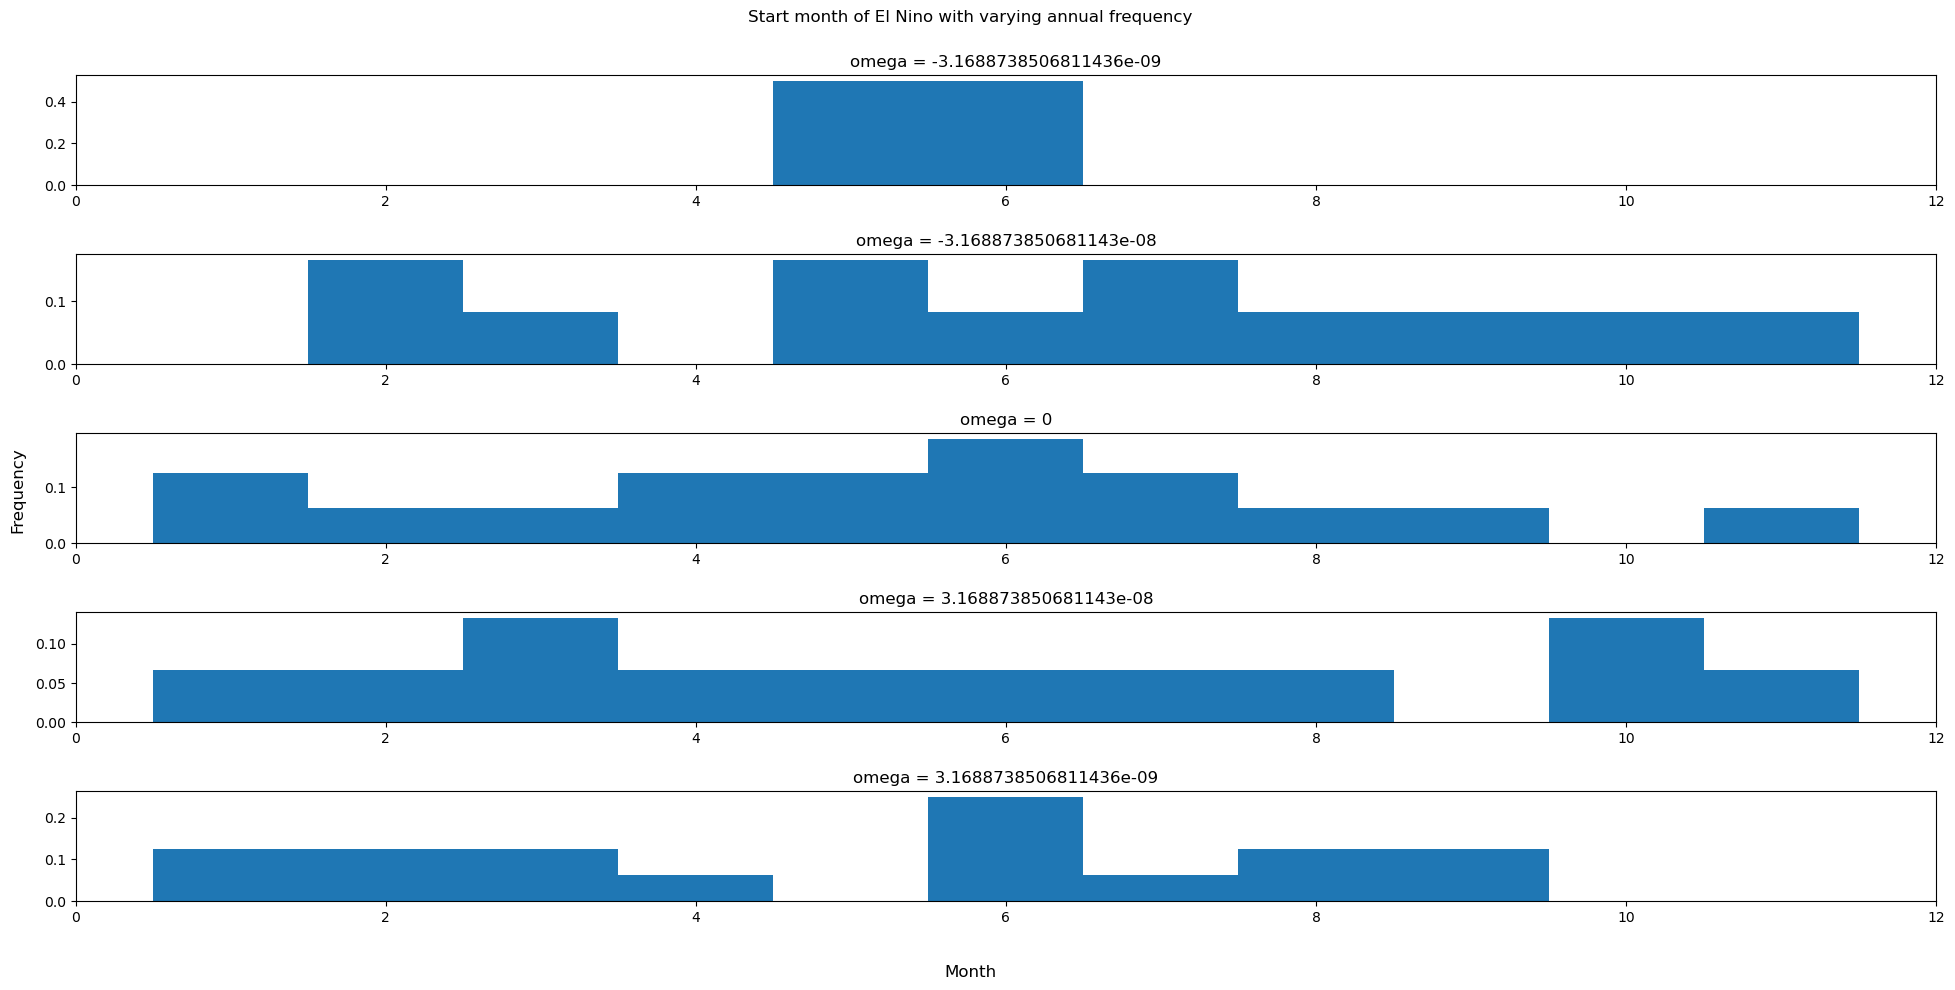

In [38]:
fig, axs = plt.subplots(nrows = len(init_conds), ncols = 1, figsize = (20, 10))

i = 1
for omega in init_conds:
    axs[i - 1].hist(month_of_start['omega_' + str(i)], bins = np.arange(-0.5, 12), 
                    weights = np.zeros_like(month_of_start['omega_' + str(i)]) + 1. / month_of_start['omega_' + str(i)].size)
    axs[i - 1].set_xlim(0, 12)
    axs[i - 1].set_title("omega = " + str(omega))
    i += 1

fig.supxlabel("Month")
fig.supylabel("Frequency")
fig.suptitle("Start month of El Nino with varying annual frequency")
plt.tight_layout(pad = 1.8)

While we can't exactly discern a clear pattern without knowledge of which freqency is most accurate, each non-zero frequency seems to have the highest frequency of El Niño starts around spring to early summer. This is roughly consistent with what we'd expect. 

## Part 3.2
Finally, we are asked to redo section 2, but with a $\Delta x$ appropriate for the Atlantic Ocean. Recall, that the width of the equatorial Pacific is actually $2\Delta x$. Google Maps tells us that the width of the equatorial Atlantic is roughly $5000\mathrm{km}$ from Brazil to Gabon, so a good estimate for $\Delta x$ here is about $2.5\times10^6\mathrm{m}$.

Text(0.5, 0.01, 'Year')

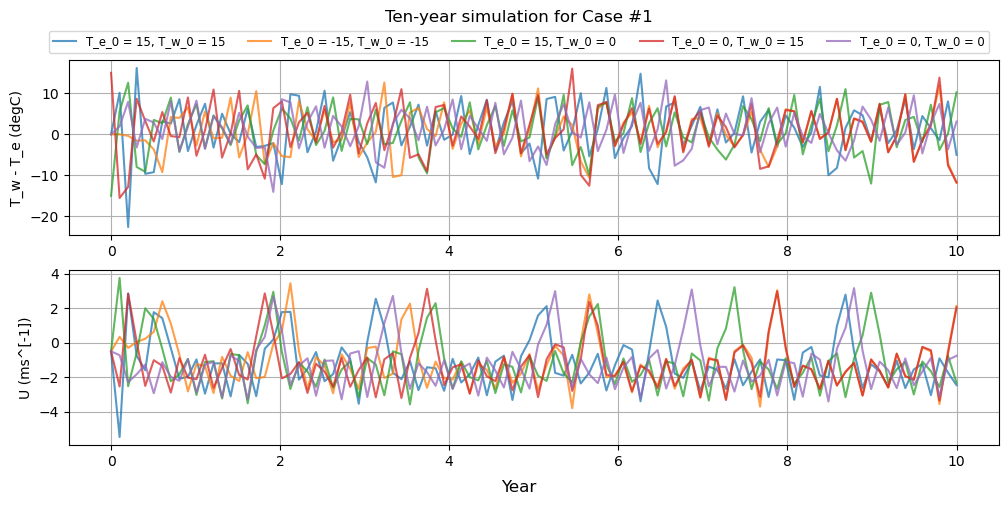

In [23]:
# Ensure our values are well-defined
del_x = 2.5 * 10**6
T_0 = 15
A = 1 / (6 / 12 * sec_year)
C = 1 / (2 / 12 * sec_year)
ten_year = np.linspace(0, sec_year * 10, 100)
sec_year = 365.2425 * 24 * 60 * 60

# Define system
def system_eq(y, t):
    U = y[0]; T_e = y[1]; T_w = y[2]
    eq_1 = B * (T_e - T_w) + C * (U_0 - U)
    eq_2 = U / del_x * T_w + A * (T_0 - T_e)
    eq_3 = -U / del_x * T_e + A * (T_0 - T_w)

    return np.array([eq_1, eq_2, eq_3])

# Vary values
U_0 = -0.5
B = 1.3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #1")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

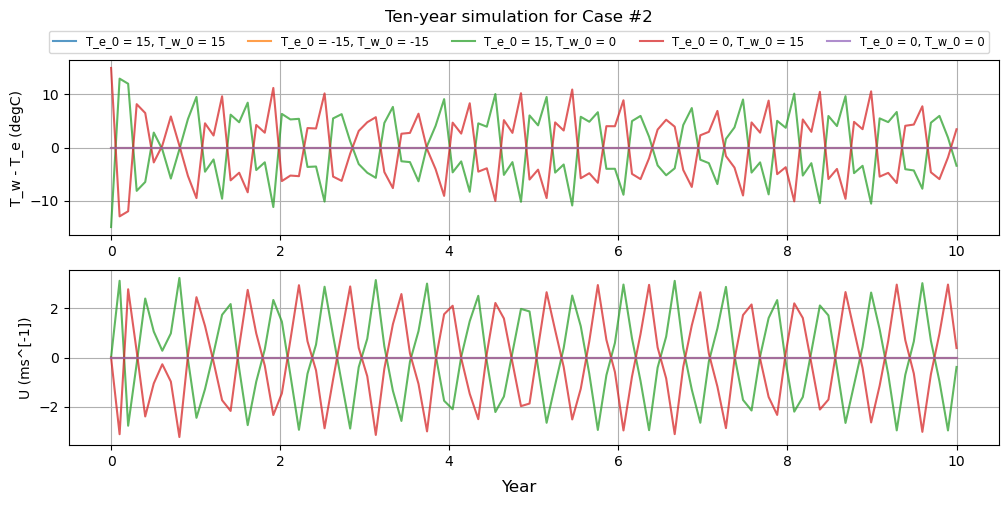

In [24]:
# Vary values
U_0 = 0
B = 1.3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #2")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

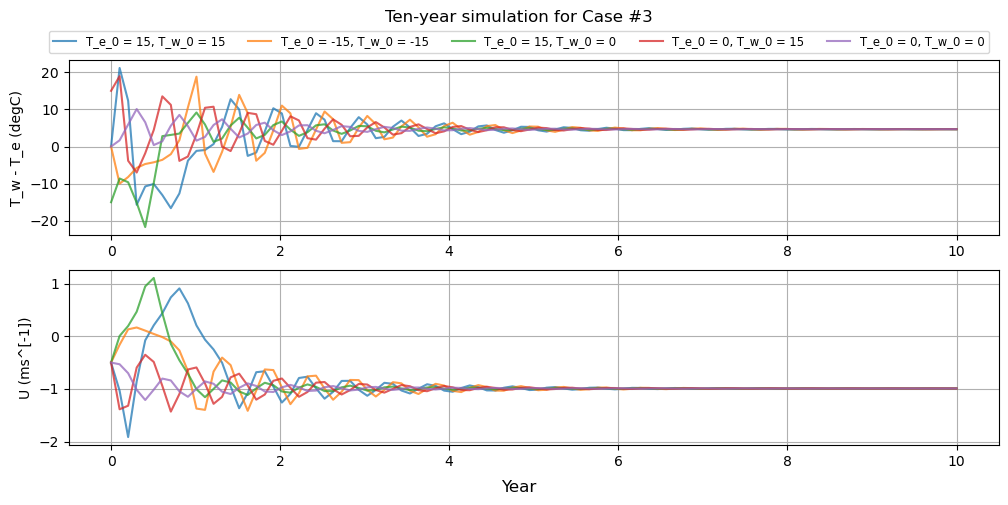

In [25]:
# Vary values
U_0 = -0.5
B = 2 * 10**(-8)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #3")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

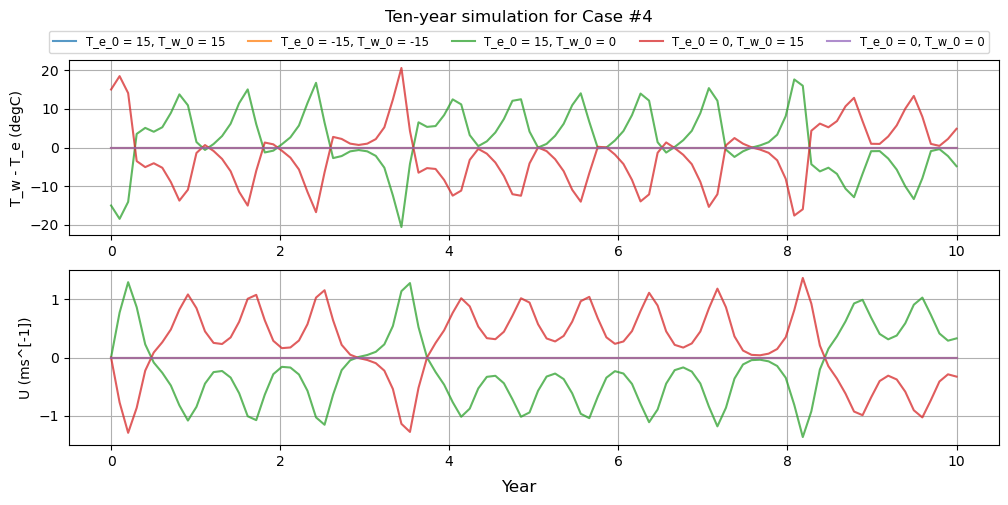

In [26]:
# Vary values
U_0 = 0
B = 2 * 10**(-8)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #4")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

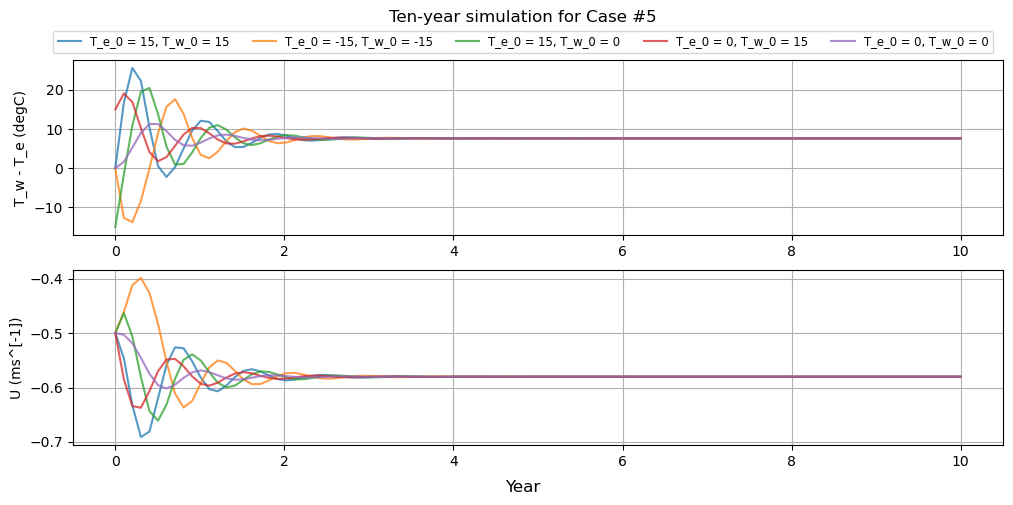

In [27]:
# Vary values
U_0 = -0.5
B = 2 * 10**(-9)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #5")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

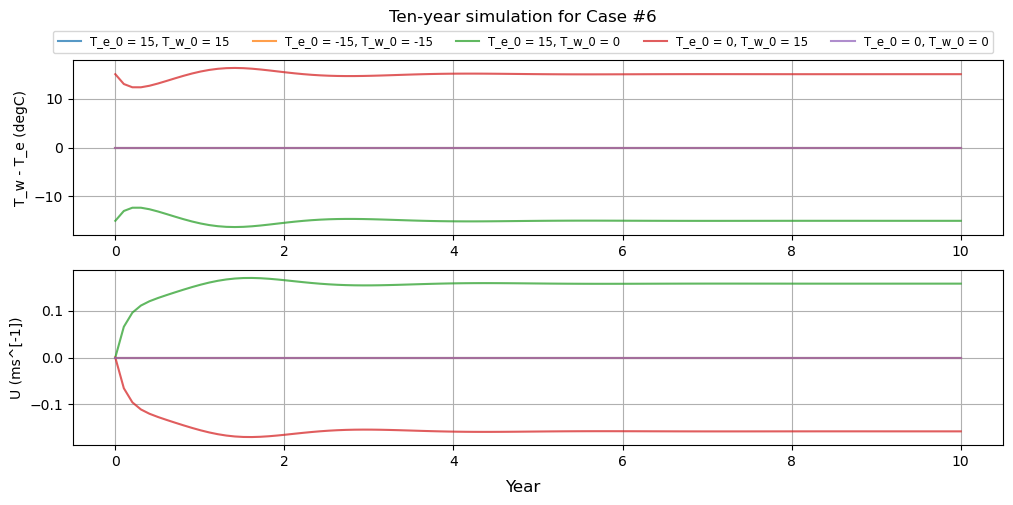

In [28]:
# Vary values
U_0 = 0
B = 2 * 10**(-9)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #6")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

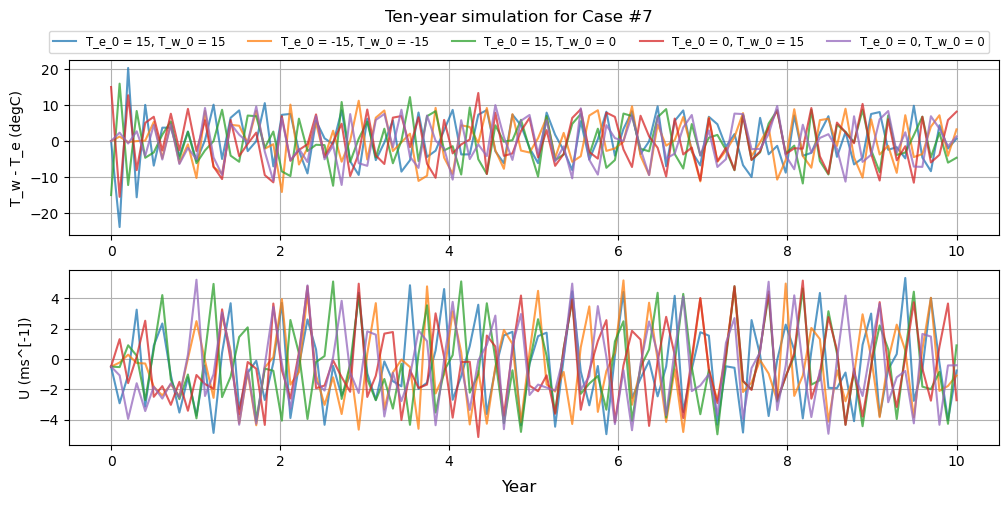

In [29]:
# Vary values
U_0 = -0.5
B = 3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #7")
fig.supxlabel("Year")

Text(0.5, 0.01, 'Year')

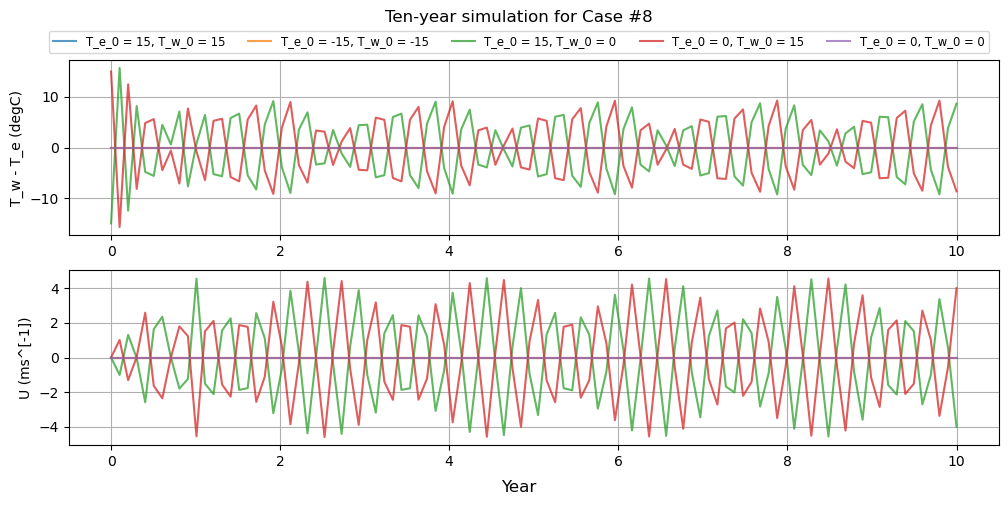

In [30]:
# Vary values
U_0 = 0
B = 3 * 10**(-7)

# Set up plot
fig, axs = plt.subplots(2, 1, figsize = (12, 5))

# Set initial conditions
init_conds = [(15, 15), (-15, -15), (15, 0), (0, 15), (0, 0)]
for conds in init_conds:

    T_e_0 = conds[0]
    T_w_0 = conds[1]
    sln = integrate.odeint(system_eq, [U_0, T_e_0, T_w_0], ten_year)
    temp_grad = sln[:,2] - sln[:,1]
    U_vary = sln[:,0]

    # Plot data
    axs[0].plot(ten_year / sec_year, temp_grad, label = "T_e_0 = " + str(T_e_0) + ", T_w_0 = " + str(T_w_0), alpha = 0.75)
    axs[1].plot(ten_year / sec_year, U_vary, alpha = 0.75)

# Label axes
axs[0].set_ylabel("T_w - T_e (degC)")
axs[1].set_ylabel("U (ms^[-1])")
[ax.grid() for ax in axs]; # Like MATLAB, mutes the line

# Set up legends
fig.legend(ncol = 5, loc = "upper center", fontsize = "small", bbox_to_anchor = [0.5, 0.95])

# Label figure
fig.suptitle("Ten-year simulation for Case #8")
fig.supxlabel("Year")

These cases seem similar to our El Niño plots, but with higher frequencies and much lower magnitudes for the current speed. Given the dramatically lower width of the Atlantic Ocean basin, we understand certainly why the system is weaker. This lower current speed is likely why we don't see as significant effects climatically from this "Atlantic El Niño".